# Task 1 — Clustering Methods
Apply hierarchical, K-means, and DBSCAN clustering on TP53 orthologs using MSA-based distances from Lab 4.

## 1. Initialize Project Environment
Import libraries for sequence analysis, clustering, and visualization.

In [18]:
from __future__ import annotations

import logging
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("sklearn imported successfully")

pandas 2.2.3
numpy 2.1.3
sklearn imported successfully


## 2. Define Configuration Parameters
Centralize paths, clustering options, and reproducibility settings.

In [19]:
@dataclass
class ClusterConfig:
    handle: str
    fasta_path: Path = None
    distance_matrix_path: Path = None  # Use Lab 4's distance matrix from proper MSA
    export_dir: Path = Path("artifacts")
    k_values: List[int] = None
    dbscan_eps: float = 0.3
    dbscan_min_samples: int = 2
    random_state: int = 42

    def __post_init__(self):
        if self.fasta_path is None:
            self.fasta_path = Path(
                f"../../../data/work/{self.handle}/lab04/tp53_multi_sequences.fasta"
            )
        if self.distance_matrix_path is None:
            # Use the distance matrix from Lab 4 (computed from proper Clustal Omega MSA)
            self.distance_matrix_path = Path(
                f"../../04_phylogenetics/assignments/artifacts/task1_distance_matrix.csv"
            )
        if self.k_values is None:
            self.k_values = [2, 3, 4]

    def describe(self) -> Dict[str, str]:
        info = asdict(self)
        info["fasta_path"] = str(info["fasta_path"])
        info["distance_matrix_path"] = str(info["distance_matrix_path"])
        info["export_dir"] = str(info["export_dir"])
        return info


CONFIG = ClusterConfig(handle="AndreiCod")
CONFIG.describe()

{'handle': 'AndreiCod',
 'fasta_path': '../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta',
 'distance_matrix_path': '../../04_phylogenetics/assignments/artifacts/task1_distance_matrix.csv',
 'export_dir': 'artifacts',
 'k_values': [2, 3, 4],
 'dbscan_eps': 0.3,
 'dbscan_min_samples': 2,
 'random_state': 42}

In [20]:
def load_sequences(cfg: ClusterConfig) -> List[SeqRecord]:
    """Load sequences from Lab 4 FASTA file."""
    if not cfg.fasta_path.exists():
        raise FileNotFoundError(f"FASTA not found: {cfg.fasta_path}")

    records = list(SeqIO.parse(cfg.fasta_path, "fasta"))
    logging.info("Loaded %d sequences from %s", len(records), cfg.fasta_path)
    return records


sequences = load_sequences(CONFIG)
seq_ids = [rec.id for rec in sequences]
print(f"Loaded {len(sequences)} sequences:")
for rec in sequences:
    print(f"  {rec.id}: {len(rec.seq)} bp")

[INFO] Loaded 10 sequences from ../../../data/work/AndreiCod/lab04/tp53_multi_sequences.fasta


Loaded 10 sequences:
  NM_000546.6: 2512 bp
  NM_011640.3: 1781 bp
  NM_131327.2: 2233 bp
  NM_001003210.1: 1174 bp
  NM_213824.3: 1849 bp
  NM_174201.2: 2175 bp
  NM_205264.1: 1555 bp
  NM_030989.3: 1792 bp
  XM_016931470.3: 2634 bp
  NM_001047151.2: 2184 bp


## 3. Implement Core Functionality
Compute pairwise distance matrix, apply clustering methods, and evaluate quality.

In [21]:
# Load distance matrix from Lab 4 (MSA-based)
if not CONFIG.distance_matrix_path.exists():
    raise FileNotFoundError(
        f"Lab 4 distance matrix not found: {CONFIG.distance_matrix_path}"
    )

dist_df = pd.read_csv(CONFIG.distance_matrix_path, index_col=0)
seq_labels = list(dist_df.index)
distance_matrix = dist_df.values
logging.info("Loaded %dx%d distance matrix from Lab 4", *distance_matrix.shape)

# Verify IDs match
assert set(rec.id for rec in sequences) == set(seq_labels), "Sequence ID mismatch"
print(f"[OK] Loaded {len(seq_labels)} sequences")
dist_df.round(4)

[INFO] Loaded 10x10 distance matrix from Lab 4


[OK] Loaded 10 sequences


,NM_000546.6,NM_001003210.1,NM_001047151.2,NM_011640.3,NM_030989.3,NM_131327.2,NM_174201.2,NM_205264.1,NM_213824.3,XM_016931470.3
NM_000546.6,0.0000,0.1652,0.0494,0.2600,0.2521,0.4878,0.2022,0.4394,0.1880,0.0022
NM_001003210.1,0.1652,0.0000,0.1705,0.2259,0.2347,0.4658,0.1899,0.3996,0.1729,0.1674
NM_001047151.2,0.0494,0.1705,0.0000,0.2696,0.2572,0.4945,0.2106,0.4635,0.2052,0.0536
NM_011640.3,0.2600,0.2259,0.2696,0.0000,0.1177,0.4981,0.2966,0.4561,0.2712,0.2346
NM_030989.3,0.2521,0.2347,0.2572,0.1177,0.0000,0.4883,0.2995,0.4568,0.2793,0.2233
NM_131327.2,0.4878,0.4658,0.4945,0.4981,0.4883,0.0000,0.4897,0.4950,0.4771,0.4918
NM_174201.2,0.2022,0.1899,0.2106,0.2966,0.2995,0.4897,0.0000,0.4347,0.1547,0.1839
NM_205264.1,0.4394,0.3996,0.4635,0.4561,0.4568,0.4950,0.4347,0.0000,0.4360,0.4290
NM_213824.3,0.1880,0.1729,0.2052,0.2712,0.2793,0.4771,0.1547,0.4360,0.0000,0.1773
XM_016931470.3,0.0022,0.1674,0.0536,0.2346,0.2233,0.4918,0.1839,0.4290,0.1773,0.0000


In [22]:
def apply_hierarchical_clustering(
    distance_matrix: np.ndarray, method: str = "average"
) -> np.ndarray:
    """Apply hierarchical clustering and return linkage matrix."""
    condensed = squareform(distance_matrix)
    Z = linkage(condensed, method=method)
    return Z


linkage_matrix = apply_hierarchical_clustering(distance_matrix)
logging.info("Hierarchical clustering complete (average linkage)")

[INFO] Hierarchical clustering complete (average linkage)


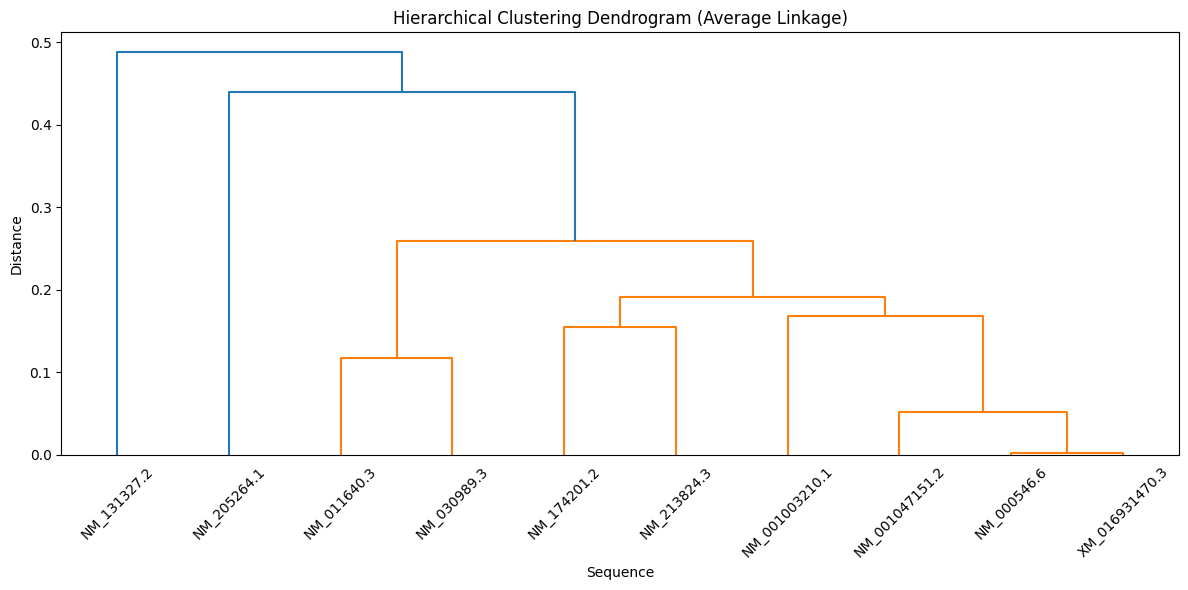

[OK] Dendrogram saved to: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_hierarchical_dendrogram.png


In [23]:
# Visualize dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=seq_labels,
    leaf_rotation=45,
    leaf_font_size=10,
)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Sequence")
plt.ylabel("Distance")
plt.tight_layout()

# Save dendrogram
EXPORT_DIR = CONFIG.export_dir
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EXPORT_DIR / "task1_hierarchical_dendrogram.png", dpi=150)
plt.show()
print(
    f"[OK] Dendrogram saved to: {(EXPORT_DIR / 'task1_hierarchical_dendrogram.png').resolve()}"
)

In [24]:
def apply_kmeans_on_distances(
    distance_matrix: np.ndarray, k: int, random_state: int = 42
):
    """Apply K-means using MDS embedding of distance matrix."""
    from sklearn.manifold import MDS

    mds = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=random_state,
        normalized_stress="auto",
    )
    embedding = mds.fit_transform(distance_matrix)
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    return kmeans.fit_predict(embedding), embedding


# Test K-means with K=2,3,4
kmeans_results = {}
for k in CONFIG.k_values:
    labels, embedding = apply_kmeans_on_distances(
        distance_matrix, k, CONFIG.random_state
    )
    sil_score = (
        silhouette_score(distance_matrix, labels, metric="precomputed")
        if 2 <= k < len(sequences)
        else None
    )
    kmeans_results[k] = {
        "labels": labels,
        "embedding": embedding,
        "silhouette": sil_score,
    }
    logging.info("K=%d: Silhouette=%.4f", k, sil_score or 0)

best_k = max(
    (k for k in kmeans_results if kmeans_results[k]["silhouette"]),
    key=lambda k: kmeans_results[k]["silhouette"],
)
print(f"Best K={best_k} with Silhouette={kmeans_results[best_k]['silhouette']:.4f}")

[INFO] K=2: Silhouette=0.4468
[INFO] K=3: Silhouette=0.4415
[INFO] K=4: Silhouette=0.3546


Best K=2 with Silhouette=0.4468


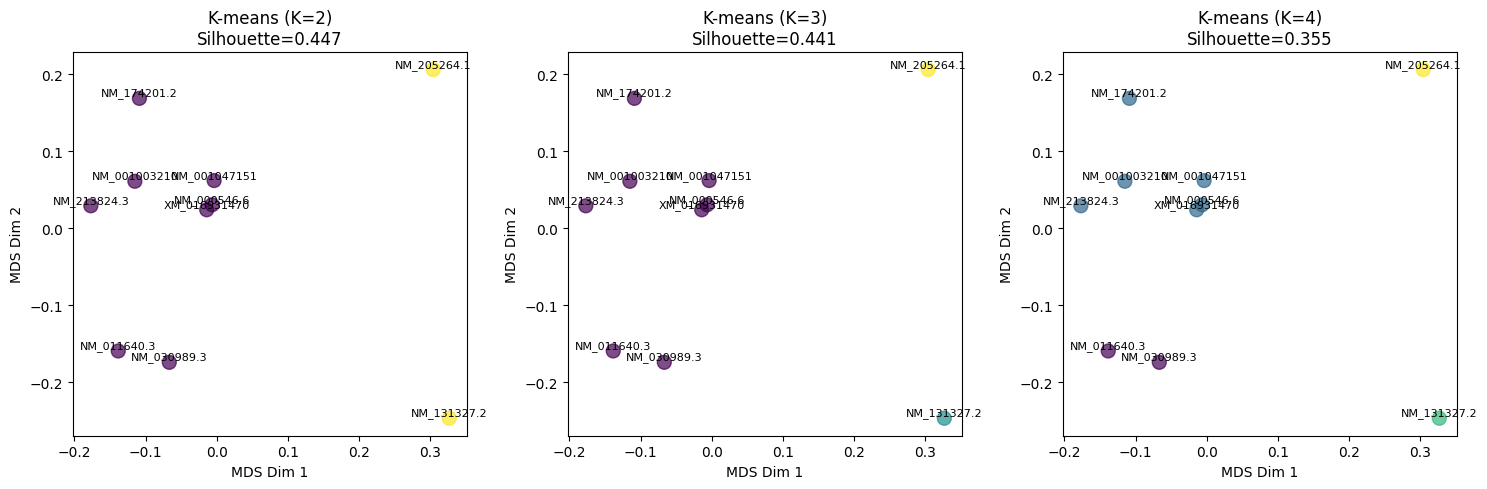

[OK] Saved: /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts/task1_kmeans_comparison.png


In [25]:
# Visualize K-means results
fig, axes = plt.subplots(1, len(CONFIG.k_values), figsize=(15, 5))
for idx, k in enumerate(CONFIG.k_values):
    ax = axes[idx]
    embedding, labels, sil = (
        kmeans_results[k]["embedding"],
        kmeans_results[k]["labels"],
        kmeans_results[k]["silhouette"],
    )
    ax.scatter(
        embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", s=100, alpha=0.7
    )
    for i, label in enumerate(seq_labels):
        ax.annotate(
            label[:12],
            (embedding[i, 0], embedding[i, 1]),
            fontsize=8,
            ha="center",
            va="bottom",
        )
    ax.set_title(
        f"K-means (K={k})\nSilhouette={sil:.3f}" if sil else f"K-means (K={k})"
    )
    ax.set_xlabel("MDS Dim 1")
    ax.set_ylabel("MDS Dim 2")

plt.tight_layout()
plt.savefig(EXPORT_DIR / "task1_kmeans_comparison.png", dpi=150)
plt.show()
print(f"[OK] Saved: {(EXPORT_DIR / 'task1_kmeans_comparison.png').resolve()}")

In [26]:
def apply_dbscan_on_distances(
    distance_matrix: np.ndarray, eps: float, min_samples: int
) -> np.ndarray:
    """Apply DBSCAN clustering on distance matrix."""
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="precomputed")
    labels = dbscan.fit_predict(distance_matrix)
    return labels


# Test multiple eps AND min_samples values (as required by assignment)
eps_values = [0.2, 0.3, 0.4, 0.5]
min_samples_values = [2, 3]  # Vary min_samples as required
dbscan_results = {}

for eps in eps_values:
    for min_samp in min_samples_values:
        key = (eps, min_samp)
        labels = apply_dbscan_on_distances(distance_matrix, eps, min_samp)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        # Silhouette score (only if more than 1 cluster and not all noise)
        valid_labels = labels[labels != -1]
        if n_clusters >= 2 and len(valid_labels) >= 2:
            valid_idx = labels != -1
            valid_dist = distance_matrix[valid_idx][:, valid_idx]
            sil_score = silhouette_score(
                valid_dist, labels[valid_idx], metric="precomputed"
            )
        else:
            sil_score = None

        dbscan_results[key] = {
            "labels": labels,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette": sil_score,
            "eps": eps,
            "min_samples": min_samp,
        }
        logging.info(
            "eps=%.2f, min_samples=%d: %d clusters, %d noise, Silhouette=%s",
            eps,
            min_samp,
            n_clusters,
            n_noise,
            f"{sil_score:.4f}" if sil_score else "N/A",
        )

# Summary table
dbscan_summary = pd.DataFrame(
    [
        {
            "eps": r["eps"],
            "min_samples": r["min_samples"],
            "n_clusters": r["n_clusters"],
            "n_noise": r["n_noise"],
            "silhouette": r["silhouette"],
        }
        for r in dbscan_results.values()
    ]
)
print("\nDBSCAN Parameter Sweep (eps × min_samples):")
dbscan_summary

[INFO] eps=0.20, min_samples=2: 2 clusters, 2 noise, Silhouette=0.4432
[INFO] eps=0.20, min_samples=3: 1 clusters, 4 noise, Silhouette=N/A
[INFO] eps=0.30, min_samples=2: 1 clusters, 2 noise, Silhouette=N/A
[INFO] eps=0.30, min_samples=3: 1 clusters, 2 noise, Silhouette=N/A
[INFO] eps=0.40, min_samples=2: 1 clusters, 1 noise, Silhouette=N/A
[INFO] eps=0.40, min_samples=3: 1 clusters, 1 noise, Silhouette=N/A
[INFO] eps=0.50, min_samples=2: 1 clusters, 0 noise, Silhouette=N/A
[INFO] eps=0.50, min_samples=3: 1 clusters, 0 noise, Silhouette=N/A



DBSCAN Parameter Sweep (eps × min_samples):


,eps,min_samples,n_clusters,n_noise,silhouette
0,0.2,2,2,2,0.443208
1,0.2,3,1,4,NaN
2,0.3,2,1,2,NaN
3,0.3,3,1,2,NaN
4,0.4,2,1,1,NaN
5,0.4,3,1,1,NaN
6,0.5,2,1,0,NaN
7,0.5,3,1,0,NaN


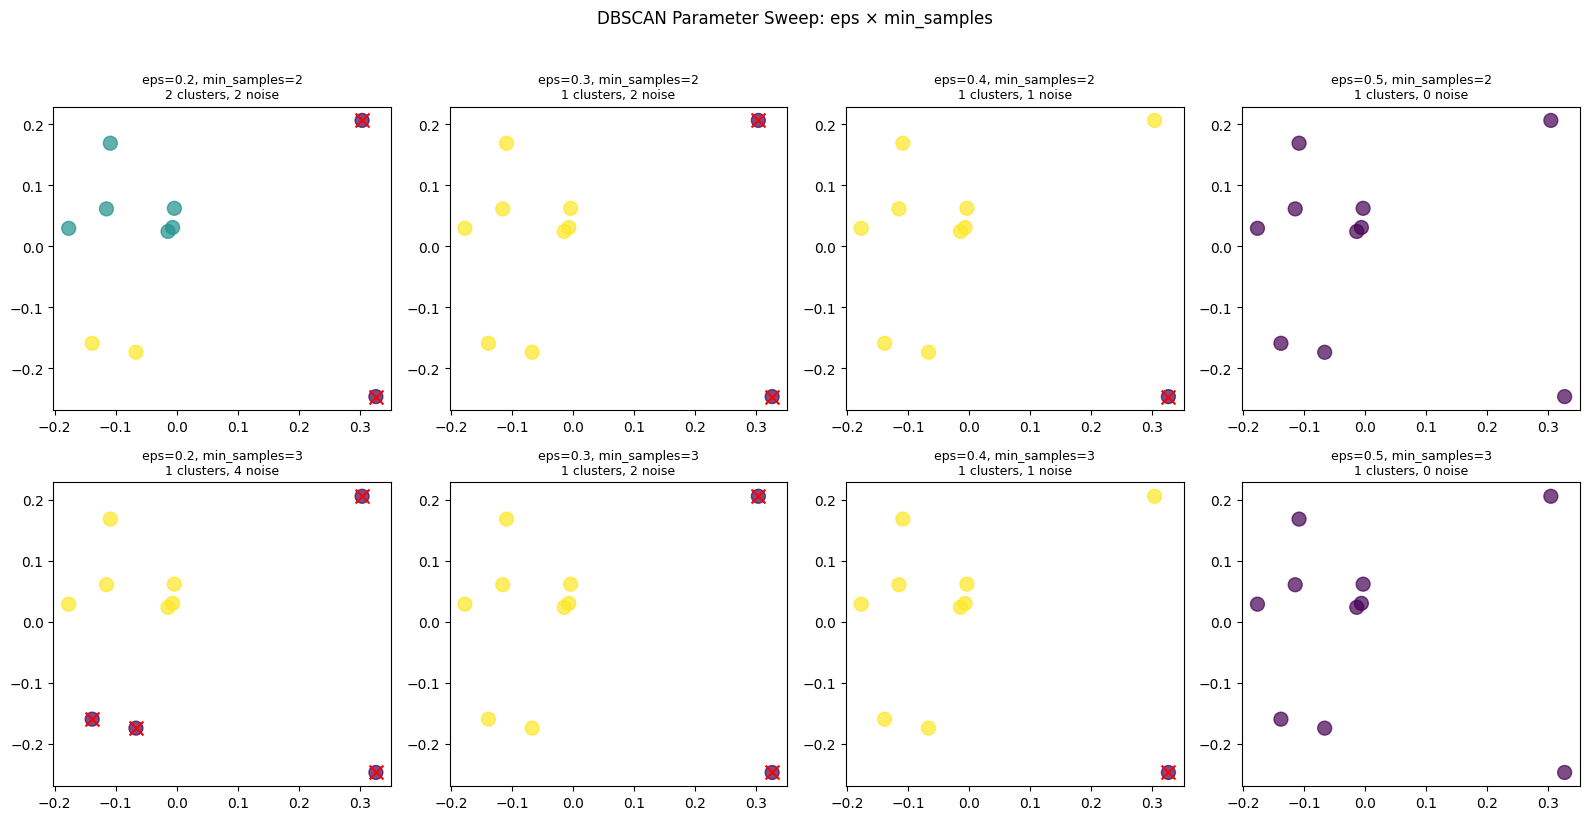

In [27]:
# Visualize DBSCAN results with varying eps AND min_samples
embedding = kmeans_results[best_k]["embedding"]
fig, axes = plt.subplots(len(min_samples_values), len(eps_values), figsize=(16, 8))

for i, min_samp in enumerate(min_samples_values):
    for j, eps in enumerate(eps_values):
        ax = axes[i, j]
        result = dbscan_results[(eps, min_samp)]
        labels = result["labels"]
        noise_mask = labels == -1

        ax.scatter(
            embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", s=100, alpha=0.7
        )
        ax.scatter(
            embedding[noise_mask, 0],
            embedding[noise_mask, 1],
            c="red",
            marker="x",
            s=100,
        )
        ax.set_title(
            f"eps={eps}, min_samples={min_samp}\n{result['n_clusters']} clusters, {result['n_noise']} noise",
            fontsize=9,
        )

plt.suptitle("DBSCAN Parameter Sweep: eps × min_samples", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "task1_dbscan_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Validate with Unit Tests
Quick checks to ensure distance computation and clustering behave correctly.

In [28]:
# Unit tests
assert np.allclose(distance_matrix, distance_matrix.T), "Distance matrix not symmetric"
assert np.allclose(np.diag(distance_matrix), 0), "Diagonal not zero"
for k, result in kmeans_results.items():
    assert len(result["labels"]) == len(seq_labels)

# Biological sanity check: primates closer than fish
human_chimp = dist_df.loc["NM_000546.6", "XM_016931470.3"]
human_fish = dist_df.loc["NM_000546.6", "NM_131327.2"]
assert human_chimp < human_fish and human_chimp < 0.1
print(f"[OK] Human-Chimp: {human_chimp:.4f}, Human-Fish: {human_fish:.4f}")

[OK] Human-Chimp: 0.0022, Human-Fish: 0.4878


## 5. Export Results
Save clustering labels, quality metrics, and distance matrix to artifacts.

In [29]:
# Create comprehensive results DataFrame
results_df = pd.DataFrame({"sequence_id": seq_labels})

# Add hierarchical clusters at different cut heights
for n_clusters in [2, 3]:
    hc_labels = fcluster(linkage_matrix, n_clusters, criterion="maxclust")
    results_df[f"Hierarchical_K{n_clusters}"] = hc_labels

# Add K-means results
for k, result in kmeans_results.items():
    results_df[f"KMeans_K{k}"] = result["labels"]

# Add DBSCAN results for different parameter combinations
best_dbscan_key = (0.3, 2)  # Default reasonable choice
results_df[f"DBSCAN_eps0.3_min2"] = dbscan_results[best_dbscan_key]["labels"]

# Also add another parameter combination for comparison
results_df[f"DBSCAN_eps0.4_min2"] = dbscan_results[(0.4, 2)]["labels"]

results_df

,sequence_id,Hierarchical_K2,Hierarchical_K3,KMeans_K2,KMeans_K3,KMeans_K4,DBSCAN_eps0.3_min2,DBSCAN_eps0.4_min2
0,NM_000546.6,1,1,0,0,1,0,0
1,NM_001003210.1,1,1,0,0,1,0,0
2,NM_001047151.2,1,1,0,0,1,0,0
3,NM_011640.3,1,1,0,0,0,0,0
4,NM_030989.3,1,1,0,0,0,0,0
5,NM_131327.2,2,3,1,1,2,-1,-1
6,NM_174201.2,1,1,0,0,1,0,0
7,NM_205264.1,1,2,1,2,3,-1,0
8,NM_213824.3,1,1,0,0,1,0,0
9,XM_016931470.3,1,1,0,0,1,0,0


In [30]:
# Save all artifacts
import json

# Cluster labels
results_df.to_csv(EXPORT_DIR / "task1_cluster_labels.csv", index=False)

# Distance matrix (copy from Lab 4 for completeness)
dist_df.to_csv(EXPORT_DIR / "task1_distance_matrix.csv")


# Quality metrics (convert numpy types to Python types for JSON)
def to_json_safe(val):
    if hasattr(val, "tolist"):
        return val.tolist()  # numpy arrays
    if hasattr(val, "item"):
        return val.item()  # numpy scalars
    return val


quality_metrics = {
    "kmeans": {
        str(k): {"silhouette": to_json_safe(r["silhouette"])}
        for k, r in kmeans_results.items()
    },
    "dbscan": {
        f"eps{r['eps']}_min{r['min_samples']}": {
            "eps": r["eps"],
            "min_samples": r["min_samples"],
            "n_clusters": r["n_clusters"],
            "n_noise": r["n_noise"],
            "silhouette": to_json_safe(r["silhouette"]),
        }
        for r in dbscan_results.values()
    },
    "best_kmeans_k": best_k,
    "best_kmeans_silhouette": to_json_safe(kmeans_results[best_k]["silhouette"]),
}
with open(EXPORT_DIR / "task1_quality_metrics.json", "w") as f:
    json.dump(quality_metrics, f, indent=2)

print(f"All Task 1 artifacts saved to {EXPORT_DIR.resolve()}")

All Task 1 artifacts saved to /home/rbals/git/daha-bdhb/BDHB-lab/labs/05_clustering/assignments/artifacts
